<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load the Image
We will use `requests` to fetch the image and `PIL` to open it, then convert it to a NumPy array.

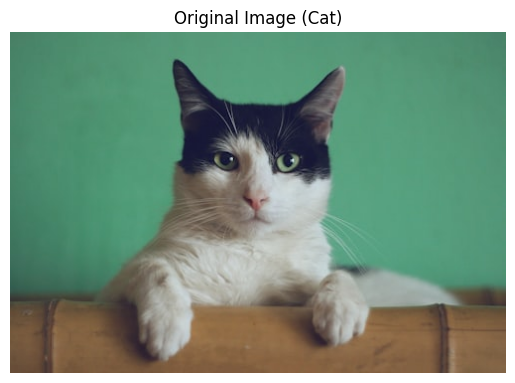

In [6]:
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Using a reliable Unsplash cat image URL to avoid 403 errors
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=500&auto=format&fit=crop"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    img_pil = Image.open(BytesIO(response.content)).convert("RGB")
    img_array = np.array(img_pil)

    plt.imshow(img_array)
    plt.title("Original Image (Cat)")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error loading image: {e}")

### 2. Crop the Image
Using NumPy slicing to take a 200x200 crop from the center.

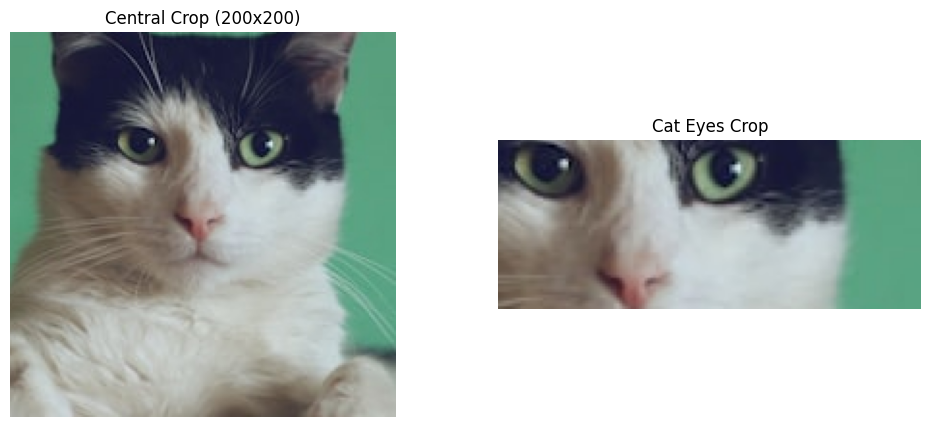

In [13]:
if 'img_array' in globals():
    h, w, _ = img_array.shape

    # 1. General Central Crop (200x200)
    start_h, start_w = h // 2 - 100, w // 2 - 100
    cropped_img = img_array[max(0, start_h) : start_h + 200, max(0, start_w) : start_w + 200]

    # 2. Specific Crop focusing on the Eyes
    # Based on the original image, the eyes are roughly in this region
    eyes_crop = img_array[120:180, 200:350]

    # Displaying both
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cropped_img)
    axes[0].set_title("Central Crop (200x200)")
    axes[0].axis('off')

    axes[1].imshow(eyes_crop)
    axes[1].set_title("Cat Eyes Crop")
    axes[1].axis('off')

    plt.show()
else:
    print("Error: img_array not defined. Please run the loading cell first.")

### 3. Flip the Image
Using NumPy's `[::-1]` syntax to flip the image vertically.

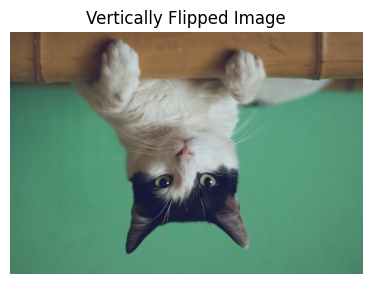

In [15]:
if 'img_array' in globals():
    # 1. NumPy indexing for vertical flip
    flipped_img = img_array[::-1, :, :]

    # 2. NumPy indexing for a crop focusing on the eyes
    # We define the eye region coordinates based on the original image dimensions
    eyes_crop = img_array[120:180, 200:350]

    # Displaying the results
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(flipped_img)
    plt.title("Vertically Flipped Image")
    plt.axis('off')

    plt.show()
else:
    print("Error: img_array not defined. Please run the loading cell first.")

### 4. CNN Model Definition
We define a simple Convolutional Neural Network using Keras to process our images.

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2

# Define a simple CNN model
model = models.Sequential([
    layers.Input(shape=(200, 200, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 313632)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     3,136,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137,226 (11.97 MB)

 Trainable params: 3,137,226 (11.97 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Applying CNN to Rotated Images
We will now rotate the cropped image by 0, 90, 180, and 270 degrees and pass each through the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


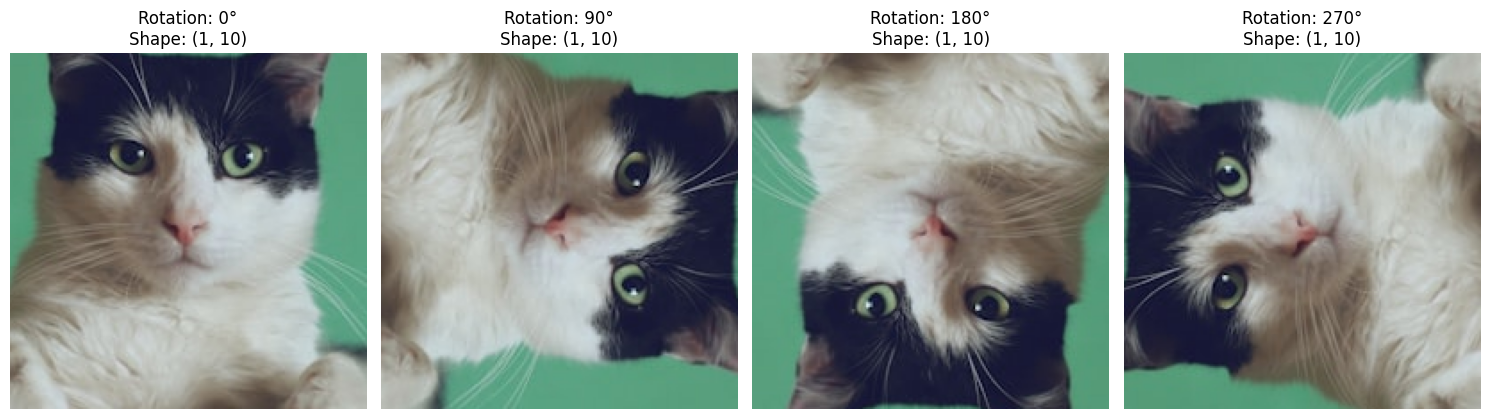

In [12]:
def process_image(image, rotation_code):
    if rotation_code is not None:
        rotated = cv2.rotate(image, rotation_code)
    else:
        rotated = image

    # Preprocess: ensure size is 200x200, normalize, and add batch dimension
    resized = cv2.resize(rotated, (200, 200))
    normalized = resized.astype('float32') / 255.0
    input_tensor = np.expand_dims(normalized, axis=0)

    # Predict
    prediction = model.predict(input_tensor)
    return rotated, prediction

rotations = [
    (None, "0°"),
    (cv2.ROTATE_90_CLOCKWISE, "90°"),
    (cv2.ROTATE_180, "180°"),
    (cv2.ROTATE_90_COUNTERCLOCKWISE, "270°")
]

plt.figure(figsize=(15, 5))
for i, (code, label) in enumerate(rotations):
    rot_img, pred = process_image(cropped_img, code)
    plt.subplot(1, 4, i+1)
    plt.imshow(rot_img)
    plt.title(f"Rotation: {label}\nShape: {pred.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()